<a href="https://colab.research.google.com/github/XanderPatterson/4487-IS-Class-Labs/blob/main/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

Choose a City & Upload Your Dataset
📥 Follow these steps:

Go to: https://insideairbnb.com/get-the-data/
Choose a city you’re interested in.
Download the file named: listings.csv.gz under that city.
In your notebook:
Open the left sidebar
Click the folder icon 📁
Click the upload icon ⬆️ and choose your listings.csv.gz file
Use the file path /content/listings.csv.gz when loading your data.
Import standard libraries (pandas, numpy, seaborn, matplotlib)

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("listings (2).csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,NaN,1,0,1,0,1.24
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,NaN,NaN,2,0,2,0,2.12


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

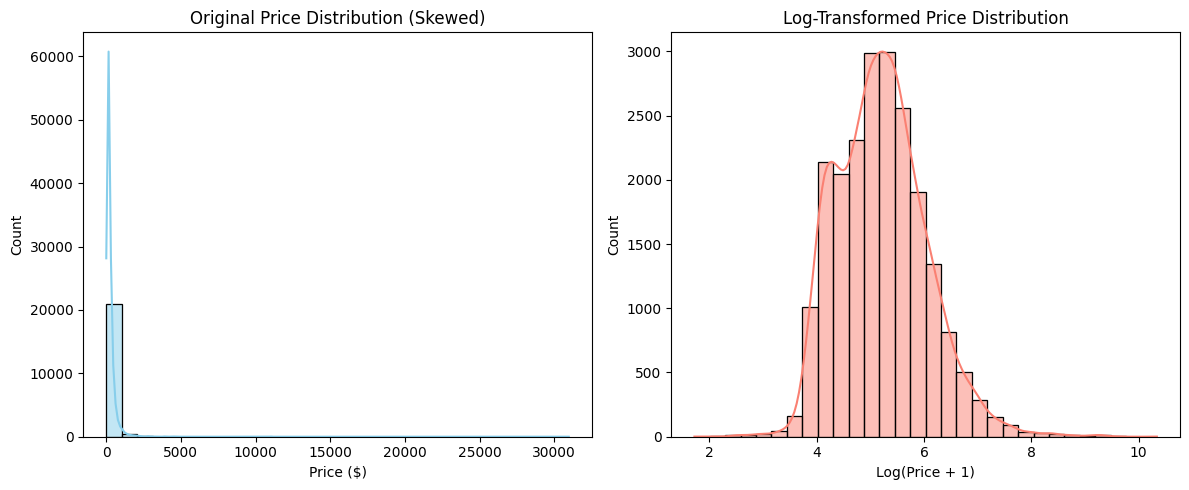

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if df['price'].dtype == 'object': df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'].dropna(), bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Price Distribution (Skewed)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

df['price_log'] = np.log1p(df['price'])
sns.histplot(df['price_log'].dropna(), bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Reflection:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?

### ✍️ Your Response: 🔧
1. I looked at the price column

2. I used the log transformation because raw price data is right skewed by a lot becuase there aren't a lot of the more expensive listing or luxury listings. So this is keeping it more normal price constricted. Using the log compresses the large outlier data and stretches out the lower values. This coverts it to a more normal looking distribution.

3. The log transformation helped take the more righ skewed data and brought it more compressed so the outliers didn't effect the data so much. This made it so that it was a more normal distribution look. For businesses and stakholders or even the host this makes it easier to see prices along the more stadard look and not have it really affected by the outliers.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale
scaler_minmax = MinMaxScaler()
df['minimum_nights_minmax'] = scaler_minmax.fit_transform(df[['minimum_nights']])

# Z-score scale
scaler_standard = StandardScaler()
df['number_of_reviews_zscore'] = scaler_standard.fit_transform(df[['number_of_reviews']])
df[['minimum_nights', 'minimum_nights_minmax', 'number_of_reviews', 'number_of_reviews_zscore']].head()


,minimum_nights,minimum_nights_minmax,number_of_reviews,number_of_reviews_zscore
0,30.0,0.025824,10,-0.283333
1,30.0,0.025824,198,2.094078
2,30.0,0.025824,2,-0.384499
3,30.0,0.025824,251,2.764306
4,30.0,0.025824,423,4.939384



### Reflection:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

### ✍️ Your Response: 🔧
1. I scaled the number of reviews and minimum nights. I used the min max scaling for minimum nights which made the values into a range between 0 and 1. Then I used zscore or the standard scaler that made the data have a mean of 0 and a std dev of 1.

2. These values can be more useful when it comes to the machine learning. This can help with things like outliers and things that are pulling the model towards a certain skewed direction.

3. Machine leaning engineers and data scientists: They get more accurate, quick, and better unbiased informatino about the data. This also helps with finding the best algorighms or finding the best recommendations to help keep the data more consistent and more understandable.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

In [5]:
import pandas as pd

bins = [-1, 10, 50, float('inf')]
labels = ['Low', 'Medium', 'High']

df['review_volume'] = pd.cut(df['number_of_reviews'], bins=bins, labels=labels)

print(df['review_volume'].value_counts())

df[['number_of_reviews', 'review_volume']].head()

review_volume
Low       18584
Medium     6241
High       5434
Name: count, dtype: int64


,number_of_reviews,review_volume
0,10,Low
1,198,High
2,2,Low
3,251,High
4,423,High


### Reflection:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?

### ✍️ Your Response: 🔧
1. I grouped with the numbers of reviews into the three catigories of low, medium, and High.

2. Numbers can sometimes be kind of messy because there is a lot going on and there can be a lot of them. Grouping it like this can give it a smaller catigory and give you a better estimation for where the data is.

3. I think the marketing team could really benefit from this and be able to help see how targeting certain segments like tips and items from review. This will help show the top high performers and what there reviews meant over the lower review ones.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

In [6]:
df['price_per_person'] = df['price'] / df['accommodates']

df['is_long_term_stay'] = (df['minimum_nights'] >= 30).astype(int)

df[['price', 'accommodates', 'price_per_person', 'minimum_nights', 'is_long_term_stay']].head()

,price,accommodates,price_per_person,minimum_nights,is_long_term_stay
0,113.97,2,56.985,30.0,1
1,117.27,3,39.090,30.0,1
2,80.06,1,80.060,30.0,1
3,77.17,1,77.170,30.0,1
4,202.47,2,101.235,30.0,1


### Reflection:
1. What two new columns did you create and why?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧
1. Price per person and long term stay. The price per person because it helps normalize the pricing so that we can take the value regarding the size of the listing. The long term stay to see the long term stays of over 30 days. This helps divide the short term vacation rentals from the short term properties.

2. Price per person would probably be the guest staying there to find the best budget friendy option based on how many people are going. And the long term stay would be for the people in charge of regulation in the state or city to make sure they are following the correct standards.

3. The price of person would help identify the higher value listings and also help find the best price available for them. Long term stay would help people that are looking for monthly stays and helps the city officals monitor the city.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

In [7]:
import pandas as pd

room_type_encoded = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)

df = pd.concat([df, room_type_encoded], axis=1)

encoded_cols = [col for col in df.columns if col.startswith('room_type_')]
df[['room_type'] + encoded_cols].head()

,room_type,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,Private room,0,0,1,0
1,Entire home/apt,1,0,0,0
2,Private room,0,0,1,0
3,Private room,0,0,1,0
4,Private room,0,0,1,0


### Reflection:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?

### ✍️ Your Response: 🔧
1. I made room type because it can't take the text type models in the machine learning and so it needs to be able to process the data in  number form.
2. The get dummies one hot encoding. It helps get the right room types and gets it number form. It is unordered and so that helps even more.
3. Pricing models would tranform the machin learning models so that they can assign a coefficent to each room type and allows the model to estimate price. Dashboards and business reports will have binary indicator columns thta will be easier to filter, aggregate, or even calculate specific metrics for individual catigories.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [8]:
df.to_csv("cleaned_airbnb_data_7.csv", index=False)

print("Dataset successfully exported as 'cleaned_airbnb_data_7.csv'!")

Dataset successfully exported as 'cleaned_airbnb_data_7.csv'!


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### Reflection:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. I thought that the log transformation was important. This is one of the most important metrics  and can change the whole data set. The raw data was very right skewed so this helped more.

2. A Host would be the long term stay and review volume becuase the bins would provide immediate segments to understand the performance. The Analyst would be the minium nights and the number of reviews. The one hot encoded helped prepare the data set for the machine learning to prepared it for what was needed.

3. Making a dashboard would need the important variables like price per person and room type to help users see the rates across places to stay and also the type of stay they will be having. Having filters as well based on reviews and how long the stays are would help the hosts to see the competitors and which areas are doing better.
4. My learning outcomes were things that I wanted to learn more about what I am doing now. To be able to take straight raw data and convert it into things that I can use to help myself or a certain business. I see how much of this data was scrambled or not able to be used how I would have liked and doing this project allowed me to change what I needed to. This just helps make the data more accurate and useful.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [9]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"

[NbConvertApp] Converting notebook assignment_07_data_transformation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 408892 bytes to assignment_07_data_transformation.html
